In [1]:
#importing relevant libraries
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
# Importing the MNIST dataset using TensorFlow Datasets
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
# Splitting the dataset into training and testing sets
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# Calculating the number of validation samples (10% of the training dataset)
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)  # Convert to integer

# Calculating the number of test samples
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)  # Convert to integer

# Function to scale the image data to a range of 0 to 1
def scale(image, label):
    image = tf.cast(image, tf.float32)  # Convert image to float32
    image /= 255.  # Normalize pixel values to range [0, 1]
    return image, label  # Return the scaled image and its corresponding label

# Apply scaling to the training and validation datasets
scaled_train_and_validation_data = mnist_train.map(scale)

# Apply scaling to the test dataset
test_data = mnist_test.map(scale)

# Defining a buffer size for shuffling the training and validation datasets
BUFFER_SIZE = 10000

# Shuffle the training and validation data for better training
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

# Splitting the shuffled data into validation and training sets
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)  # Take validation samples
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)  # Skip validation samples to get training data

# Setting the batch size for training
BATCH_SIZE = 100

# Batch the training data
train_data = train_data.batch(BATCH_SIZE)

# Batch the validation data (single batch containing all validation samples)
validation_data = validation_data.batch(num_validation_samples)

# Batch the test data (single batch containing all test samples)
test_data = test_data.batch(num_test_samples)

# Extract a single batch of validation data inputs and targets for evaluation
validation_inputs, validation_targets = next(iter(validation_data))

In [2]:
input_size = 784
output_size = 10
hidden_layer_size_1 =256
hidden_layer_size_2 =128
hidden_layer_size_3 =128


model = tf.keras.Sequential([
                            tf.keras.layers.Flatten(input_shape=(28,28,1)),
                            tf.keras.layers.Dense(hidden_layer_size_1, activation='sigmoid'), #1st hidden layer
                            tf.keras.layers.Dense(hidden_layer_size_2, activation='sigmoid'), #2nd hidden layer
                            tf.keras.layers.Dense(hidden_layer_size_3, activation='sigmoid'), #2nd hidden layer

                            tf.keras.layers.Dense(output_size, activation='softmax')   
                            ])

C:\Users\kdpco\OneDrive\Documents\docs\anaconda\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [4]:
#train model
NUM_EPOCHS = 15
history=model.fit(train_data,epochs=NUM_EPOCHS,validation_data=(validation_inputs, validation_targets), verbose=2)

Epoch 1/15
540/540 - 9s - 17ms/step - accuracy: 0.7978 - loss: 0.7079 - val_accuracy: 0.9223 - val_loss: 0.2655
Epoch 2/15
540/540 - 5s - 10ms/step - accuracy: 0.9369 - loss: 0.2146 - val_accuracy: 0.9493 - val_loss: 0.1712
Epoch 3/15
540/540 - 5s - 9ms/step - accuracy: 0.9557 - loss: 0.1507 - val_accuracy: 0.9635 - val_loss: 0.1272
Epoch 4/15
540/540 - 5s - 10ms/step - accuracy: 0.9663 - loss: 0.1158 - val_accuracy: 0.9695 - val_loss: 0.1056
Epoch 5/15
540/540 - 4s - 8ms/step - accuracy: 0.9729 - loss: 0.0922 - val_accuracy: 0.9740 - val_loss: 0.0885
Epoch 6/15
540/540 - 4s - 8ms/step - accuracy: 0.9776 - loss: 0.0738 - val_accuracy: 0.9807 - val_loss: 0.0717
Epoch 7/15
540/540 - 5s - 9ms/step - accuracy: 0.9815 - loss: 0.0599 - val_accuracy: 0.9807 - val_loss: 0.0660
Epoch 8/15
540/540 - 4s - 7ms/step - accuracy: 0.9857 - loss: 0.0497 - val_accuracy: 0.9823 - val_loss: 0.0593
Epoch 9/15
540/540 - 4s - 7ms/step - accuracy: 0.9877 - loss: 0.0415 - val_accuracy: 0.9878 - val_loss: 0.042

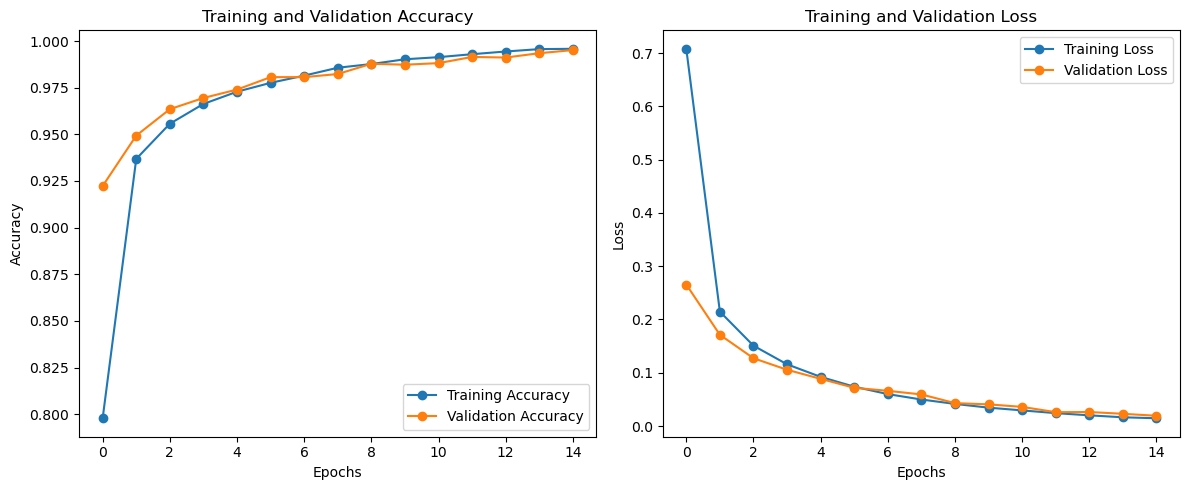

In [6]:
# Plot training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

In [7]:
test_loss,test_accuracy = model.evaluate(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step - accuracy: 0.9780 - loss: 0.0845


In [8]:
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

Test loss: 0.08. Test accuracy: 97.80%


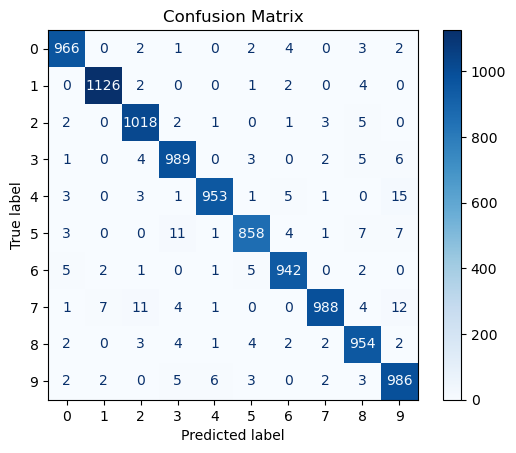

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Extract predictions and true labels
y_pred = []
y_true = []

# Iterate through the test dataset
for images, labels in test_data:
    predictions = model(images)  # Get model predictions
    predicted_classes = np.argmax(predictions.numpy(), axis=1)  # Convert to class indices
    y_pred.extend(predicted_classes)  # Append predictions
    y_true.extend(labels.numpy())  # Append true labels

# Convert to numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


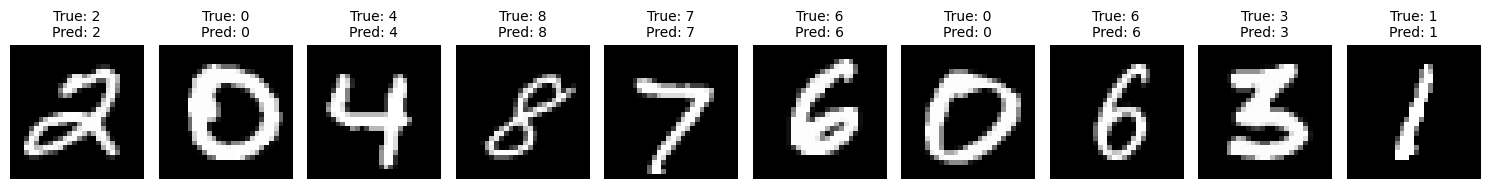

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Function to display images with true and predicted labels
def display_predictions(model, test_data, num_images=10):
    """Displays a few test images with true and predicted labels."""
    plt.figure(figsize=(15, 5))  # Adjust the figure size
    images_shown = 0  # Counter for images displayed
    
    for images, labels in test_data:
        predictions = model.predict(images)  # Get predictions for the batch
        predicted_classes = np.argmax(predictions, axis=1)  # Convert logits to predicted class
        
        for i in range(len(images)):
            if images_shown >= num_images:
                break  # Stop once we've displayed the required number of images
            
            plt.subplot(1, num_images, images_shown + 1)  # Create a subplot
            plt.imshow(images[i].numpy().squeeze(), cmap='gray')  # Display the image
            plt.axis('off')  # Turn off axes
            
            # Display the true and predicted labels
            true_label = labels[i].numpy()
            predicted_label = predicted_classes[i]
            plt.title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)
            
            images_shown += 1  # Increment the counter
        
        if images_shown >= num_images:
            break  # Exit the loop once required images are displayed

    plt.tight_layout()  # Ensure proper spacing
    plt.show()

# Call the function to display images
display_predictions(model, test_data, num_images=10)
